# Logistic Regression Model
## Imports

In [ ]:
!pip install findspark

import findspark
findspark.init()
import pyspark
import time
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.ml.feature import HashingTF, IDF, Tokenizer, StringIndexer, CountVectorizer, NGram, VectorAssembler, ChiSqSelector
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression,LinearSVC,NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from datetime import datetime

In [ ]:
!pip install -q gdown
!gdown --fuzzy "https://drive.google.com/file/d/1lu4tQ32SgpBAPENFkNMjgA2GX8fdVV3h/view?usp=sharing"


Downloading...
From (original): https://drive.google.com/uc?id=1lu4tQ32SgpBAPENFkNMjgA2GX8fdVV3h
From (redirected): https://drive.google.com/uc?id=1lu4tQ32SgpBAPENFkNMjgA2GX8fdVV3h&confirm=t&uuid=b7a896b0-b00e-4f1f-8b23-ad8370489424
To: /content/training.1600000.processed.noemoticon.csv
100% 239M/239M [00:03<00:00, 77.3MB/s]


## Context Variables


In [ ]:
spark1 = SparkSession.builder\
            .master("local[16]")\
            .appName("LR_Twitter")\
            .config("spark.driver.memory", "40g")\
            .config("spark.executor.memory", "40g")\
            .config("spark.driver.maxResultSize", "0")\
            .getOrCreate()
path = "/content/training.1600000.processed.noemoticon.csv"

schema = StructType([
    StructField("target", IntegerType(), True),
    StructField("id", StringType(), True),
    StructField("date", StringType(), True),
    StructField("query", StringType(), True),
    StructField("author", StringType(), True),
    StructField("tweet", StringType(), True)])

## Dataset Loading and Train/Test Split


In [ ]:
import os
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive zaten mount edilmiş.")


Mounted at /content/drive


In [ ]:
df = spark1.read.csv(path,
                     inferSchema=True,
                     header=False,
                     schema=schema)

df = df.dropna()

In [ ]:
# Hedef değişkenin (target) dağılımını görerek sınıf dengesini kontrol etme
# Sentiment140 setinde genellikle 0=Negatif, 4=Pozitif gelir.
df.groupBy("target").count().show()

+------+------+
|target| count|
+------+------+
|     0|800000|
|     4|800000|
+------+------+



In [ ]:
from pyspark.sql.functions import col, regexp_replace, lower, when

# 1. Etiket değerlerini normalize etme (4 değerini 1 yapma)
df = df.withColumn("target", when(col("target") == 4, 1).otherwise(col("target")))

# 2. Metin temizleme işlemleri (Regex kullanarak)
# Linkleri temizle
df = df.withColumn("tweet", regexp_replace(col("tweet"), "https?://[A-Za-z0-9./]+", ""))
# @Kullanıcı adlarını temizle
df = df.withColumn("tweet", regexp_replace(col("tweet"), "@[A-Za-z0-9_]+", ""))
# Özel karakterleri temizleyip sadece harfleri bırakma
df = df.withColumn("tweet", regexp_replace(col("tweet"), "[^a-zA-Z]", " "))
# Küçük harfe çevirme ve fazla boşlukları silme
df = df.withColumn("tweet", lower(col("tweet")))
df = df.withColumn("tweet", regexp_replace(col("tweet"), " +", " "))

# "&" ile başlayan ve ";" ile biten tüm HTML ifadelerini (örn: &quot; &amp; &lt;) siler.
df = df.withColumn("tweet", regexp_replace(col("tweet"), "&[a-z]+;", ""))

# Temizlik sonrası boş kalan satırları temizle
df = df.filter(col("tweet") != " ").dropna()



In [ ]:
from pyspark.sql import functions as F

# Duplikat kontrolü
total = df.count()
unique = df.dropDuplicates(["tweet"]).count()
print(f"Toplam: {total:,}")
print(f"Benzersiz: {unique:,}")
print(f"Duplikat: {total - unique:,}")

# Duplikatları kaldır
df = df.dropDuplicates(["tweet"])
print(f"\nTemizlik sonrası: {df.count():,} tweet")

Toplam: 1,596,350
Benzersiz: 1,523,867
Duplikat: 72,483

Temizlik sonrası: 1,523,867 tweet


In [ ]:
print(f"Toplam Satır Sayısı: {df.count()}")

Toplam Satır Sayısı: 1523867


In [ ]:
(train_set, test_set) = df.randomSplit([0.80, 0.20], seed = 2000)

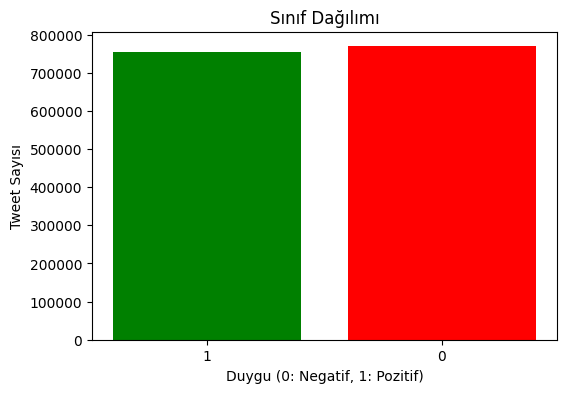

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Spark tarafında gruplama yapıp sonucu küçültüyoruz (Big Data Yöntemi)
class_distribution = df.groupBy("target").count().toPandas()

# Görselleştirme
plt.figure(figsize=(6,4))
plt.bar(class_distribution["target"].astype(str), class_distribution["count"], color=['green', 'red'])
plt.xlabel("Duygu (0: Negatif, 1: Pozitif)")
plt.ylabel("Tweet Sayısı")
plt.title("Sınıf Dağılımı")
plt.show()

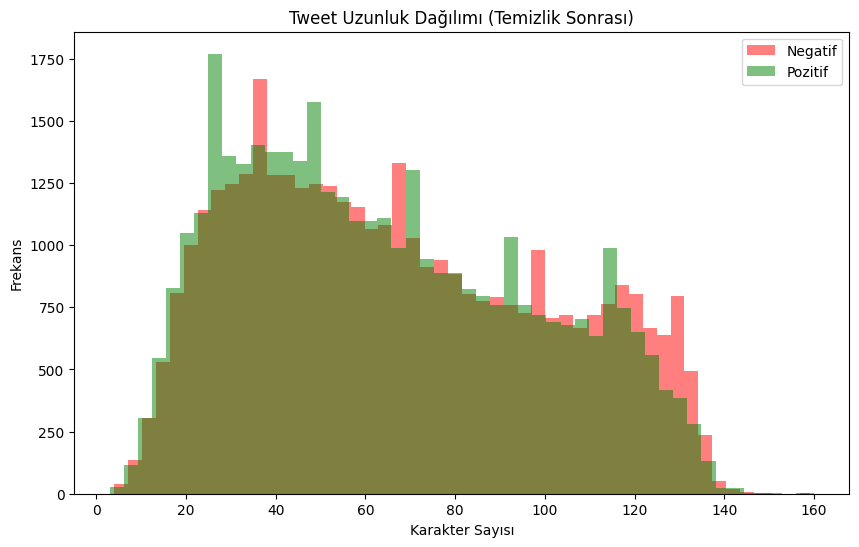

In [ ]:
from pyspark.sql.functions import length

# Tweet uzunluğunu yeni bir sütun olarak ekle
df = df.withColumn("length", length("tweet"))

# Verinin %5'lik rastgele bir kısmını alıp Pandas'a çekelim (Hız için)
sample_lengths = df.select("length", "target").sample(False, 0.05).toPandas()

# Histogram Çizimi
plt.figure(figsize=(10,6))
plt.hist(sample_lengths[sample_lengths['target']==0]['length'], bins=50, alpha=0.5, label='Negatif', color='red')
plt.hist(sample_lengths[sample_lengths['target']==1]['length'], bins=50, alpha=0.5, label='Pozitif', color='green')
plt.title("Tweet Uzunluk Dağılımı (Temizlik Sonrası)")
plt.xlabel("Karakter Sayısı")
plt.ylabel("Frekans")
plt.legend()
plt.show()

Bigram (İkili Kelime) Analizi Hazırlanıyor...


/tmp/ipython-input-10078569.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="bigram", data=bigram_counts, palette="viridis")


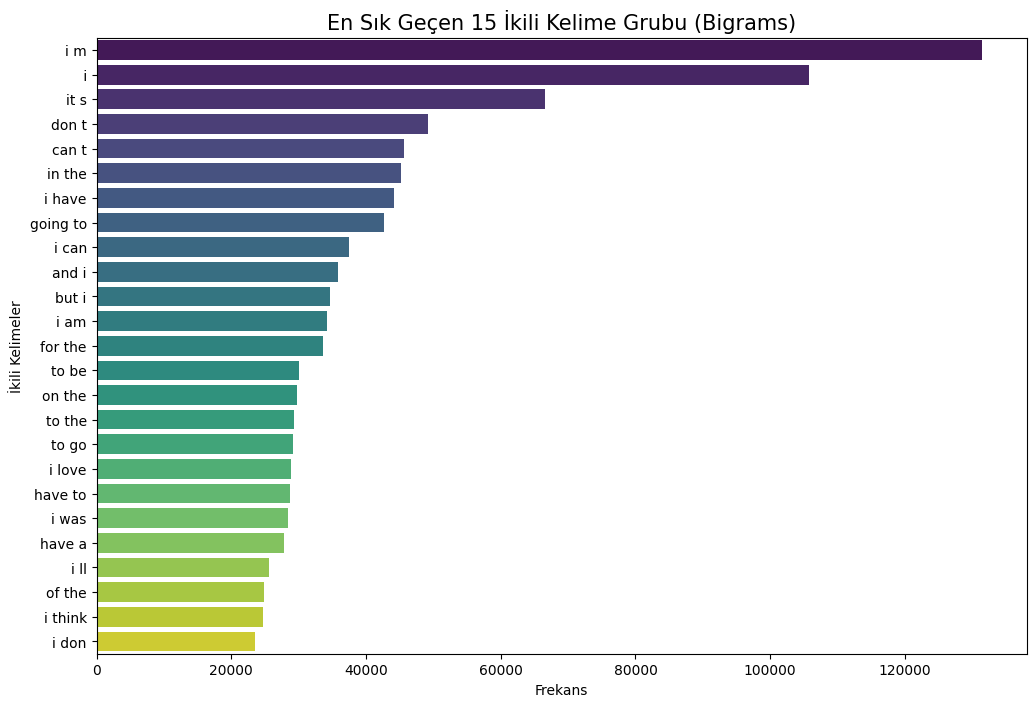

In [ ]:
from pyspark.ml.feature import NGram, Tokenizer
from pyspark.sql.functions import col, explode
import seaborn as sns

# --- BAĞLAM ANALİZİ (BIGRAMS) ---
print("Bigram (İkili Kelime) Analizi Hazırlanıyor...")

# 1. Veriyi Kelimelere Böl (Tokenizer)
# Not: Temizlenmiş veri üzerinde çalışıyoruz
tokenizer = Tokenizer(inputCol="tweet", outputCol="words")
wordsData = tokenizer.transform(df)

# 2. İkili Gruplar Oluştur (NGram)
ngram = NGram(n=2, inputCol="words", outputCol="bigrams")
ngramDataFrame = ngram.transform(wordsData)

# 3. Bigramları Patlat ve Say (Explode & Count)
# Bu işlem 'Big Data' yöntemidir; listeyi satırlara döker ve sayar.
bigram_counts = ngramDataFrame.select(explode(col("bigrams")).alias("bigram")) \
    .groupBy("bigram") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(25) \
    .toPandas()

# 4. Görselleştirme
plt.figure(figsize=(12, 8))
sns.barplot(x="count", y="bigram", data=bigram_counts, palette="viridis")
plt.title("En Sık Geçen 15 İkili Kelime Grubu (Bigrams)", fontsize=15)
plt.xlabel("Frekans")
plt.ylabel("İkili Kelimeler")
plt.show()

/tmp/ipython-input-79973616.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="author", y="count", data=top_authors, palette="rocket")


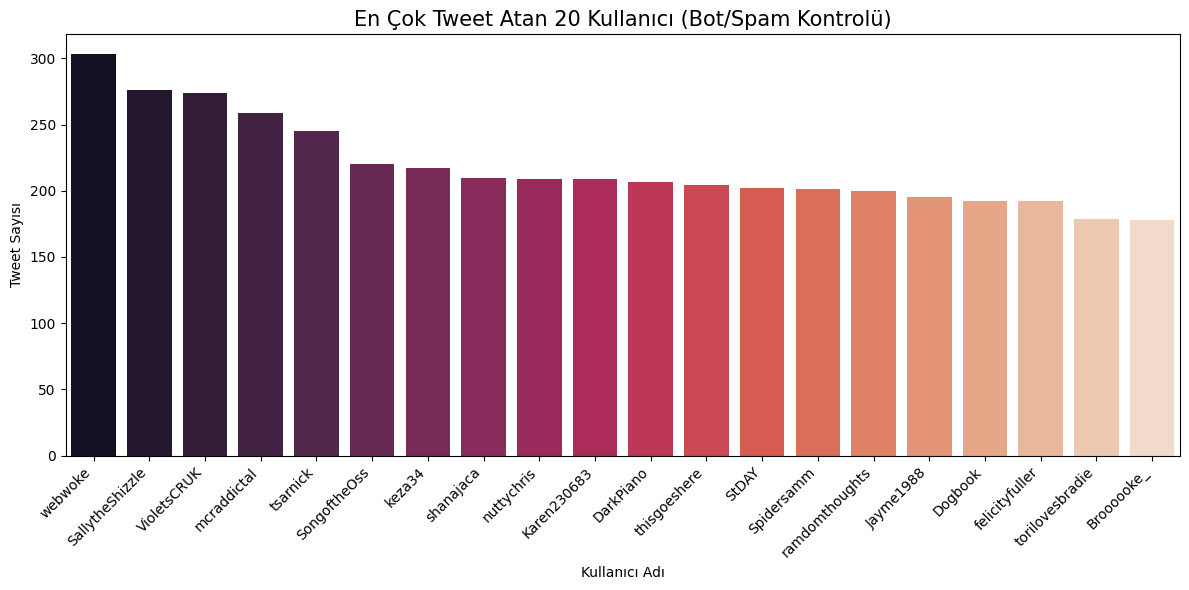

In [ ]:
# --- KULLANICI AKTİVİTE ANALİZİ ---

# En çok tweet atan 20 kullanıcıyı bul
top_authors = df.groupBy("author") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(20) \
    .toPandas()

# Görselleştirme
plt.figure(figsize=(12, 6))
sns.barplot(x="author", y="count", data=top_authors, palette="rocket")
plt.title("En Çok Tweet Atan 20 Kullanıcı (Bot/Spam Kontrolü)", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Kullanıcı Adı")
plt.ylabel("Tweet Sayısı")
plt.tight_layout()
plt.show()

Duygu bazlı kelime frekansları hesaplanıyor...


/tmp/ipython-input-1684340186.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="word", data=top_neg, ax=axes[0], palette="Reds_r")
/tmp/ipython-input-1684340186.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="word", data=top_pos, ax=axes[1], palette="Greens_r")


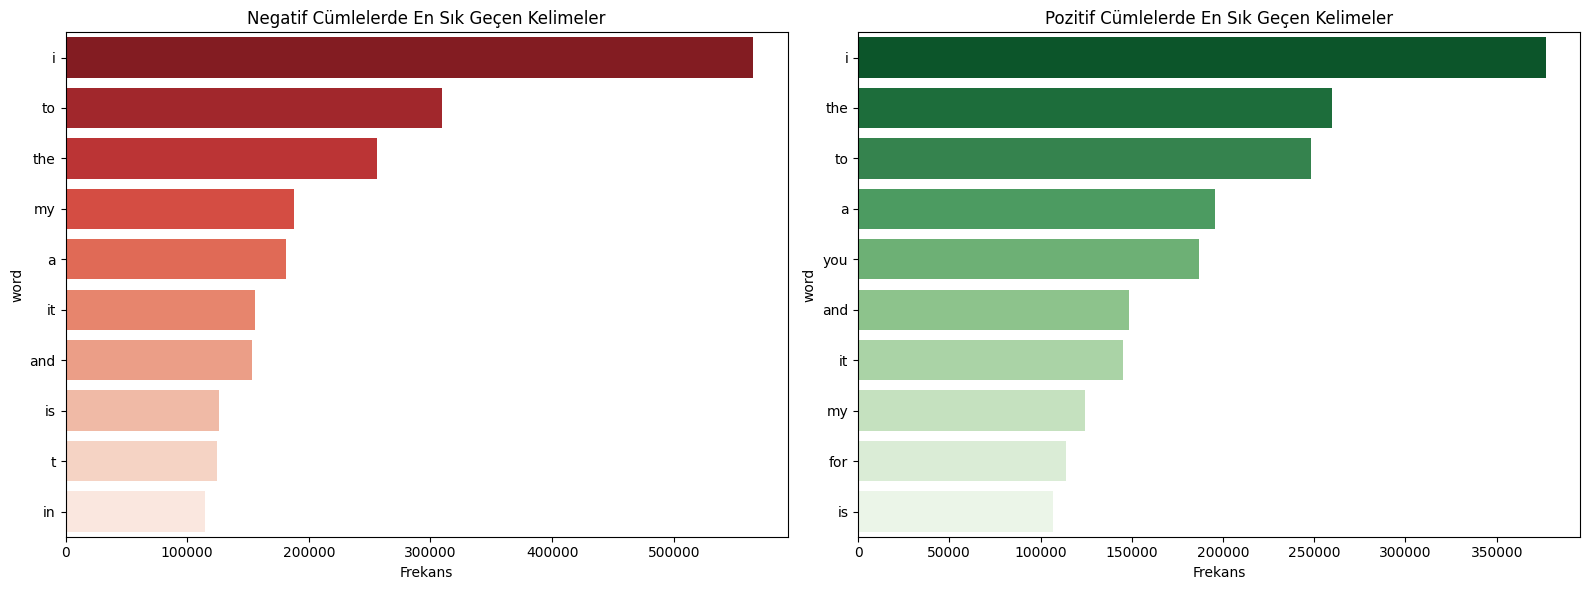

In [ ]:
# --- POZİTİF vs NEGATİF KELİME KARŞILAŞTIRMASI ---
from pyspark.sql.functions import explode, split, desc

print("Duygu bazlı kelime frekansları hesaplanıyor...")

# 1. Kelimeleri ayır (Tokenizer mantığı, boşluktan bölme)
# Sadece temizlenmiş 'tweet' kolonunu kullanıyoruz
words_df = df.withColumn("word", explode(split(col("tweet"), " ")))

# Boşlukları (empty strings) filtrele
words_df = words_df.filter(col("word") != "")

# 2. Negatif (0) ve Pozitif (1) olarak ikiye ayırıp say
top_neg = words_df.filter(col("target") == 0).groupBy("word").count().orderBy(desc("count")).limit(10).toPandas()
top_pos = words_df.filter(col("target") == 1).groupBy("word").count().orderBy(desc("count")).limit(10).toPandas()

# 3. Görselleştirme (Yan Yana Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Negatif Grafiği
sns.barplot(x="count", y="word", data=top_neg, ax=axes[0], palette="Reds_r")
axes[0].set_title("Negatif Cümlelerde En Sık Geçen Kelimeler")
axes[0].set_xlabel("Frekans")

# Pozitif Grafiği
sns.barplot(x="count", y="word", data=top_pos, ax=axes[1], palette="Greens_r")
axes[1].set_title("Pozitif Cümlelerde En Sık Geçen Kelimeler")
axes[1].set_xlabel("Frekans")

plt.tight_layout()
plt.show()

Stop Words (Etkisiz Kelimeler) Temizleniyor...


/tmp/ipython-input-2661804045.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="word", data=top_neg, ax=axes[0], palette="Reds_r")
/tmp/ipython-input-2661804045.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="word", data=top_pos, ax=axes[1], palette="Greens_r")


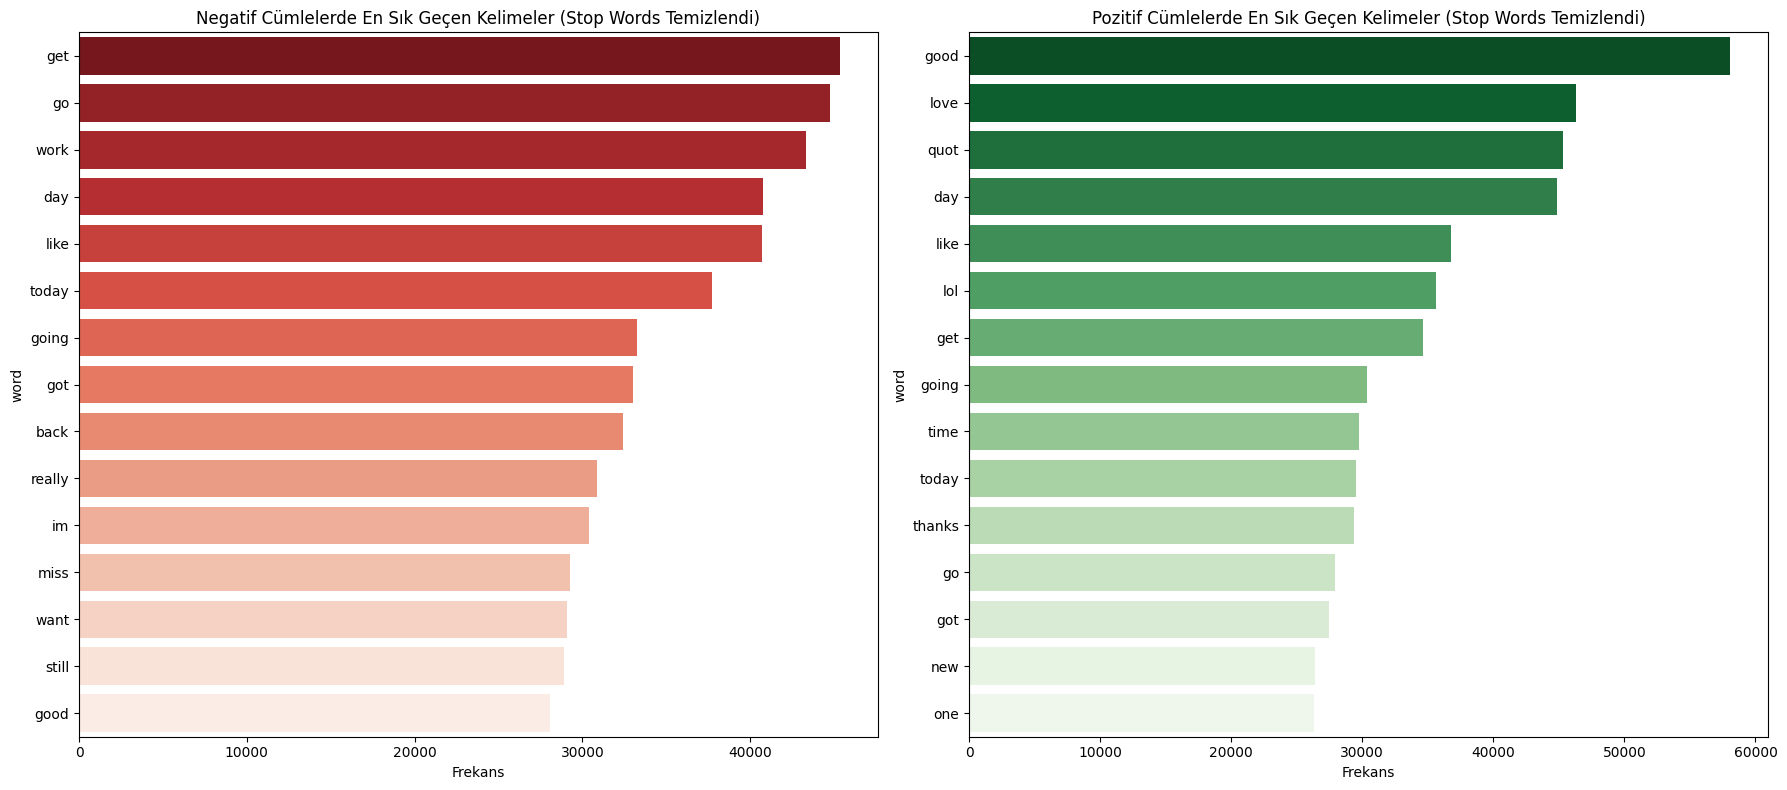

In [ ]:
from pyspark.ml.feature import StopWordsRemover, Tokenizer
from pyspark.sql.functions import col, explode, desc, length
import matplotlib.pyplot as plt
import seaborn as sns

print("Stop Words (Etkisiz Kelimeler) Temizleniyor...")

# 1) Tweetleri kelime listesine çevir
tokenizer = Tokenizer(inputCol="tweet", outputCol="raw_words")
df_words = tokenizer.transform(df)

# 2) Stopwords temizliği
remover = StopWordsRemover(inputCol="raw_words", outputCol="filtered_words")
df_clean_words = remover.transform(df_words)

# 3) Temizlenmiş kelimeleri patlat (liste -> satır)
words_exploded = df_clean_words.select(
    "target",
    explode(col("filtered_words")).alias("word")
)

# 4) boş/tek harf vb. temizliği
words_exploded_clean = words_exploded.filter(
    (col("word") != "") & (length(col("word")) > 1)
)

# 5) Negatif / pozitif top kelimeler
top_neg = (words_exploded_clean
          .filter(col("target") == 0)
          .groupBy("word").count()
          .orderBy(desc("count"))
          .limit(15)
          .toPandas())

top_pos = (words_exploded_clean
          .filter(col("target") == 1)
          .groupBy("word").count()
          .orderBy(desc("count"))
          .limit(15)
          .toPandas())

# 6) Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x="count", y="word", data=top_neg, ax=axes[0], palette="Reds_r")
axes[0].set_title("Negatif Cümlelerde En Sık Geçen Kelimeler (Stop Words Temizlendi)")
axes[0].set_xlabel("Frekans")

sns.barplot(x="count", y="word", data=top_pos, ax=axes[1], palette="Greens_r")
axes[1].set_title("Pozitif Cümlelerde En Sık Geçen Kelimeler (Stop Words Temizlendi)")
axes[1].set_xlabel("Frekans")

plt.tight_layout()
plt.show()


<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2205468905.py:23: SyntaxWarning: invalid escape sequence '\d'
  df_time = df.withColumn("hour", regexp_extract(col("date"), "(\d\d):\d\d:\d\d", 1))


+----------------------------+
|date                        |
+----------------------------+
|Tue Jun 16 03:18:48 PDT 2009|
+----------------------------+
only showing top 1 row


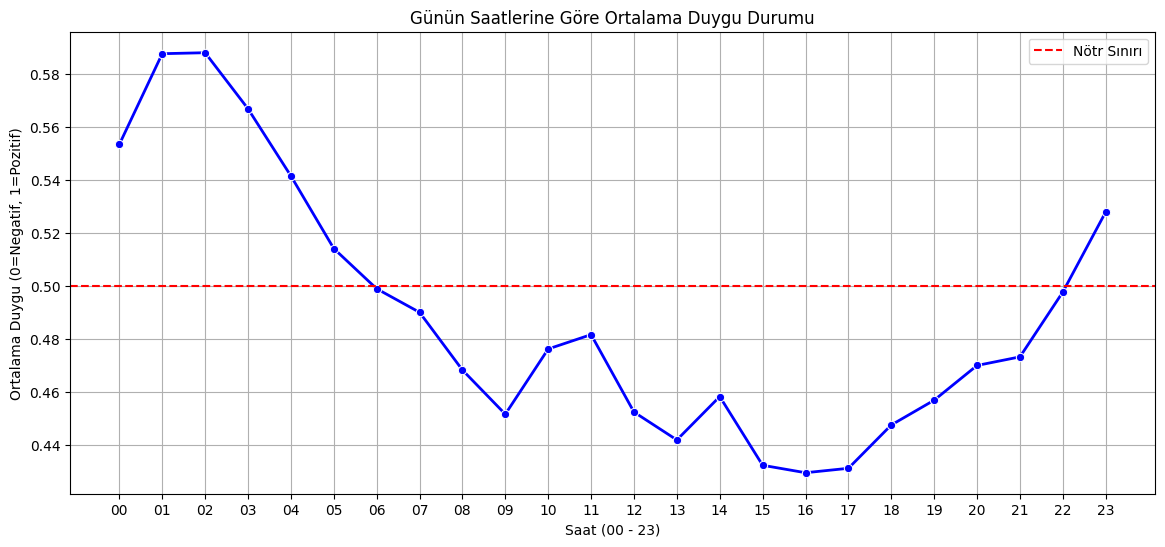

In [ ]:
# --- SAATLERE GÖRE DUYGU ANALİZİ ---
from pyspark.sql.functions import substring

# Tarih formatı örnek: "Mon Apr 06 22:19:45 PDT 2009"
# Genelde saat kısmı ortada yer alır. Basitçe string'den saati çekebiliriz.
# Eğer format sabitse (ki bu sette öyledir), substring iş görür.
# (Not: Veri setinin orijinal formatına göre indeksler değişebilir,
# ama genelde 11. karakterden itibaren saat başlar)

# Saati çekmek için (basit yöntem)
# Önce tarih sütununun yapısını kontrol etmek adına bir örnek görelim
df.select("date").show(1, truncate=False)

# Spark SQL ile saati çekme (Substring mantığı: 'YYYY-MM-DD HH:MM:SS' değilse, formatı inceleyip ayarlayacağız)
# Sentiment140 standart formatı: "Fri May 22 03:39:35 PDT 2009" -> Saat 11. karakterden başlıyor (index 12 gibi)
# Bu kısım veri setinin formatına göre hata verebilir, o yüzden önce formatı görmek lazım.
# Ama genelde şu çalışır:

# Geçici olarak 'hour' kolonu oluşturalım (Regex ile saati bulma: iki rakam : iki rakam)
from pyspark.sql.functions import regexp_extract

# "XX:XX:XX" formatındaki ilk ikiliyi (saati) al
df_time = df.withColumn("hour", regexp_extract(col("date"), "(\d\d):\d\d:\d\d", 1))

# Saatlere göre ortalama duygu (0=Negatif, 1=Pozitif)
# Eğer ortalama 0.5'in üstündeyse o saatte insanlar daha pozitif, altındaysa negatif demektir.
hourly_sentiment = df_time.groupBy("hour").agg({"target": "avg", "tweet": "count"}).orderBy("hour").toPandas()
hourly_sentiment = hourly_sentiment.rename(columns={"avg(target)": "avg_sentiment", "count(tweet)": "tweet_count"})

# Sadece geçerli saatleri al (boş veya hatalı parse edilenleri at)
hourly_sentiment = hourly_sentiment[hourly_sentiment['hour'] != ""]

# Görselleştirme
plt.figure(figsize=(14, 6))

# Çizgi grafik: Duygu Değişimi
sns.lineplot(x="hour", y="avg_sentiment", data=hourly_sentiment, marker="o", color="blue", linewidth=2)

# Referans çizgisi (0.5 nötr demektir)
plt.axhline(0.5, color='red', linestyle='--', label="Nötr Sınırı")

plt.title("Günün Saatlerine Göre Ortalama Duygu Durumu")
plt.xlabel("Saat (00 - 23)")
plt.ylabel("Ortalama Duygu (0=Negatif, 1=Pozitif)")
plt.grid(True)
plt.legend()
plt.show()

Gün bazlı duygu analizi hazırlanıyor...


/tmp/ipython-input-646873993.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="day", y="avg_sentiment", data=daily_sentiment, palette=colors)


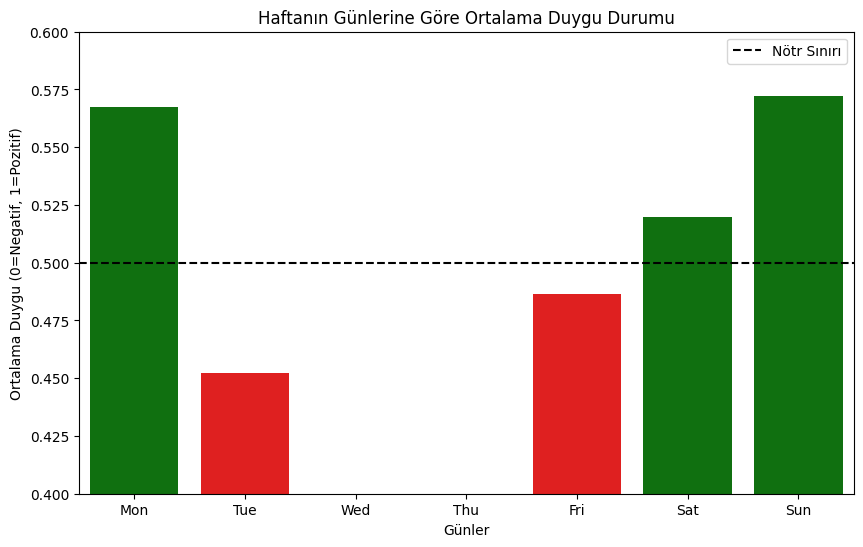

In [ ]:
from pyspark.sql.functions import substring

# --- HAFTANIN GÜNLERİNE GÖRE DUYGU ANALİZİ ---
print("Gün bazlı duygu analizi hazırlanıyor...")

# 1. Gün ismini çek (Tarih stringinin ilk 3 karakteri: Mon, Tue, Wed...)
df_days = df.withColumn("day_of_week", substring(col("date"), 1, 3))

# 2. Günlere göre ortalama duygu hesapla
daily_sentiment = df_days.groupBy("day_of_week").agg({"target": "avg"}).toPandas()
daily_sentiment.columns = ["day", "avg_sentiment"]

# 3. Günleri Sıraya Diz (Yoksa alfabetik gelir: Fri, Mon, Sat... karışır)
# Mantıklı sıra: Pazartesi -> Pazar
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily_sentiment["day"] = pd.Categorical(daily_sentiment["day"], categories=day_order, ordered=True)
daily_sentiment = daily_sentiment.sort_values("day")

# 4. Görselleştirme
plt.figure(figsize=(10, 6))
# Nötr çizgisine göre renk değiştiren bir bar plot yapalım
colors = ["red" if x < 0.5 else "green" for x in daily_sentiment["avg_sentiment"]]

sns.barplot(x="day", y="avg_sentiment", data=daily_sentiment, palette=colors)
plt.axhline(0.5, color='black', linestyle='--', label="Nötr Sınırı")
plt.ylim(0.4, 0.6) # Farkı görebilmek için Y eksenini daraltıyoruz (Duygu genelde 0.5 etrafındadır)

plt.title("Haftanın Günlerine Göre Ortalama Duygu Durumu")
plt.xlabel("Günler")
plt.ylabel("Ortalama Duygu (0=Negatif, 1=Pozitif)")
plt.legend()
plt.show()

Sayısal özelliklerin korelasyonu hesaplanıyor...


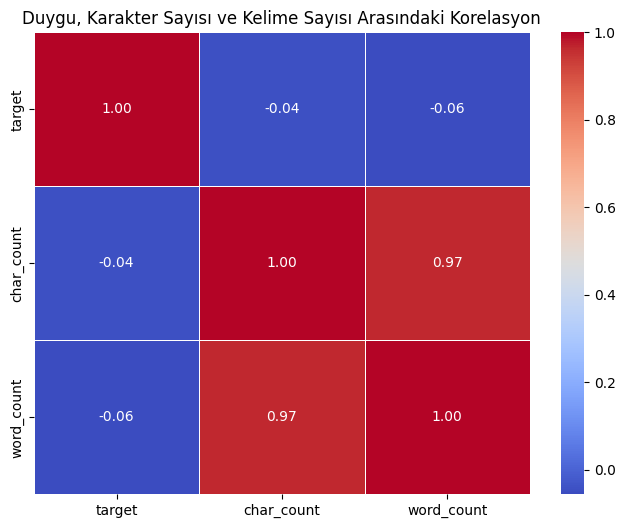

In [ ]:
import seaborn as sns
from pyspark.sql.functions import length, size, split

# --- KORELASYON ANALİZİ (Sayısal Özellikler) ---
print("Sayısal özelliklerin korelasyonu hesaplanıyor...")

# 1. Yeni Sayısal Özellikler Türetelim
# Tweet Uzunluğu (Karakter Sayısı)
df_features = df.withColumn("char_count", length(col("tweet")))
# Kelime Sayısı (Word Count)
df_features = df_features.withColumn("word_count", size(split(col("tweet"), " ")))

# 2. Analiz için veriyi Pandas'a çekelim (Sadece sayısal kolonlar)
# Not: Büyük veride 'sample' almak performans için iyidir.
corr_data = df_features.select("target", "char_count", "word_count").sample(False, 0.05, seed=42).toPandas()

# 3. Korelasyon Matrisini Hesapla
corr_matrix = corr_data.corr()

# 4. Görselleştirme (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Duygu, Karakter Sayısı ve Kelime Sayısı Arasındaki Korelasyon")
plt.show()

## HashingTF - IDF (Default Parameters)


In [ ]:
tokenizer = Tokenizer(inputCol="tweet", outputCol="words")
hashtf = HashingTF(inputCol="words", outputCol='tf')
idf = IDF(inputCol='tf', outputCol="features")
label_stringIdx = StringIndexer(inputCol = "target", outputCol = "label")


In [ ]:


lr = LogisticRegression()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, hashtf, idf, label_stringIdx, lr])

In [ ]:
%%time

st = datetime.utcnow()
pipelineFit = pipeline.fit(train_set)
print('Training time:', datetime.utcnow() - st)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

<timed exec>:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
<timed exec>:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


Training time: 0:02:01.424256
Accuracy: 0.7713224344183154
Precision: 0.7714581772146122
Recall: 0.7713224344183154
F1 Score: 0.7713229519530269
CPU times: user 158 ms, sys: 19.2 ms, total: 177 ms
Wall time: 2min 58s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_name = "HashingTF_IDF_Default_LR"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/HashingTF_IDF_Default_LR. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_HashingTF_IDF_Default_LR.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully.")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_HashingTF_IDF_Default_LR.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.771322
1  Precision  0.771458
2     Recall  0.771322
3   F1-score  0.771323


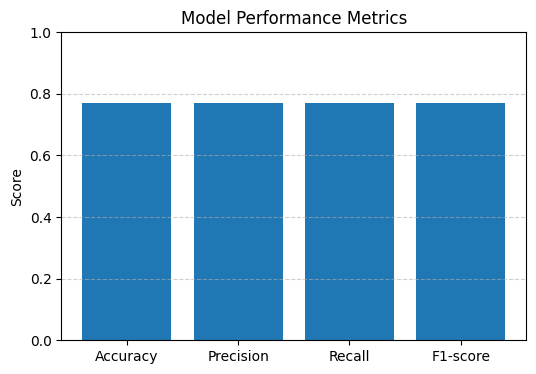

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
svm = LinearSVC()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, hashtf, idf, label_stringIdx, svm])

In [ ]:
%%time
pipelineFit = pipeline.fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7847120624478374
Precision: 0.784876956144194
Recall: 0.7847120624478374
F1 Score: 0.7847103476917361
CPU times: user 65.8 ms, sys: 15.2 ms, total: 81 ms
Wall time: 3min 21s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "HashingTF_IDF_Default_LinearSVC"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/HashingTF_IDF_Default_LinearSVC. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_HashingTF_IDF_Default_LinearSVC.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)

    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully.")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_HashingTF_IDF_Default_LinearSVC.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.784712
1  Precision  0.784877
2     Recall  0.784712
3   F1-score  0.784710


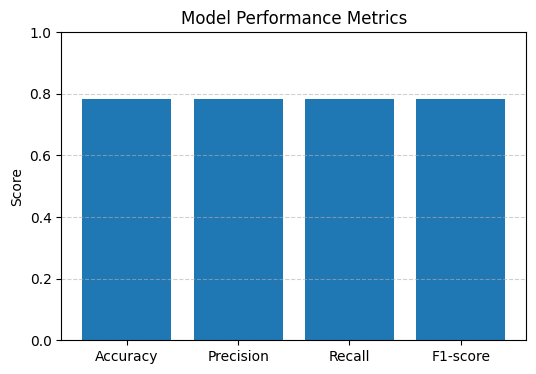

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
nb = NaiveBayes(modelType="multinomial")
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, hashtf, idf, label_stringIdx, nb])

In [ ]:
%%time
pipelineFit = pipeline.fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7512199911630418
Precision: 0.7512897583646343
Recall: 0.7512199911630418
F1 Score: 0.7511633701633155
CPU times: user 57 ms, sys: 20 ms, total: 77 ms
Wall time: 1min 29s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "HashingTF_IDF_Default_NaiveBayes"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/HashingTF_IDF_Default_NaiveBayes. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_HashingTF_IDF_Default_NaiveBayes.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully.")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_HashingTF_IDF_Default_NaiveBayes.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.751220
1  Precision  0.751290
2     Recall  0.751220
3   F1-score  0.751163


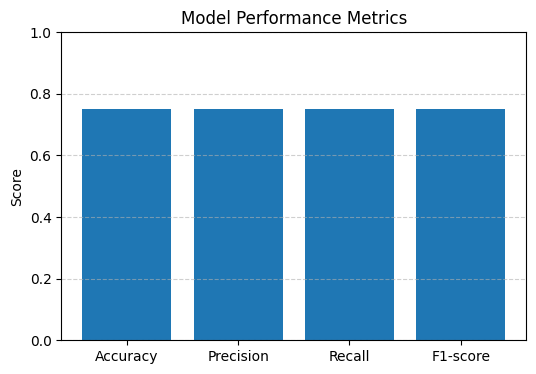

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## HashingTF–IDF (Custom Parameters)


In [ ]:
tokenizer = Tokenizer(inputCol="tweet", outputCol="words")
hashtf = HashingTF(numFeatures=2**16, inputCol="words", outputCol='tf')
idf = IDF(inputCol='tf', outputCol="features", minDocFreq=5)

label_stringIdx = StringIndexer(inputCol = "target", outputCol = "label")



In [ ]:
lr = LogisticRegression()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, hashtf, idf, label_stringIdx, lr])

In [ ]:
%%time
st = datetime.utcnow()

pipelineFit = pipeline.fit(train_set)
print('Training time:', datetime.utcnow() - st)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

<timed exec>:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
<timed exec>:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


Training time: 0:01:23.300493
Accuracy: 0.786551458916327
Precision: 0.7867881141182131
Recall: 0.7865514589163272
F1 Score: 0.7865430440065622
CPU times: user 62 ms, sys: 16.4 ms, total: 78.4 ms
Wall time: 2min 6s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "HashingTF_IDF_Custom_LR"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

Found existing model at /content/drive/MyDrive/models/HashingTF_IDF_Custom_LR. Loading...
Model loaded successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_HashingTF_IDF_Custom_LR.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_HashingTF_IDF_Custom_LR.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.786551
1  Precision  0.786788
2     Recall  0.786551
3   F1-score  0.786543


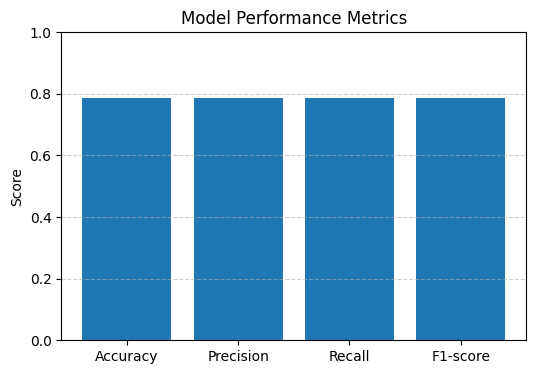

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
svm = LinearSVC()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, hashtf, idf, label_stringIdx, svm])

In [ ]:
%%time
pipelineFit = pipeline.fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7876740798926474
Precision: 0.7879254527109527
Recall: 0.7876740798926473
F1 Score: 0.7876642550729307
CPU times: user 62.1 ms, sys: 20.4 ms, total: 82.5 ms
Wall time: 2min 43s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "HashingTF_IDF_Custom_LinearSVC"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/HashingTF_IDF_Custom_LinearSVC. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd

file_name = "metrics_HashingTF_IDF_Custom_LinearSVC.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_HashingTF_IDF_Custom_LinearSVC.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.787749
1  Precision  0.788000
2     Recall  0.787749
3   F1-score  0.787740


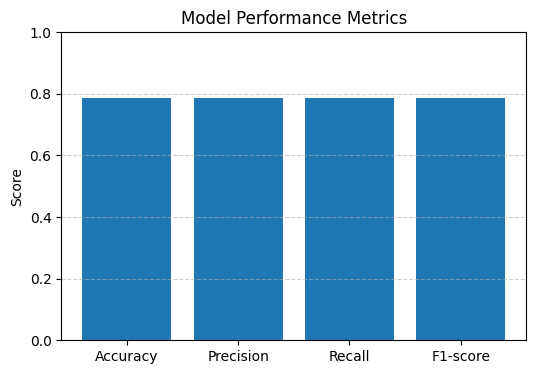

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
nb = NaiveBayes(modelType="multinomial")
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, hashtf, idf, label_stringIdx, nb])

In [ ]:
%%time
pipelineFit = pipeline.fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7586528548284157
Precision: 0.758653566888037
Recall: 0.7586528548284157
F1 Score: 0.7586370047143804
CPU times: user 51.3 ms, sys: 15.9 ms, total: 67.2 ms
Wall time: 1min 27s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "HashingTF_IDF_Custom_NaiveBayes"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/HashingTF_IDF_Custom_NaiveBayes. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_HashingTF_IDF_Custom_NaiveBayes.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_HashingTF_IDF_Custom_NaiveBayes.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.758653
1  Precision  0.758654
2     Recall  0.758653
3   F1-score  0.758637


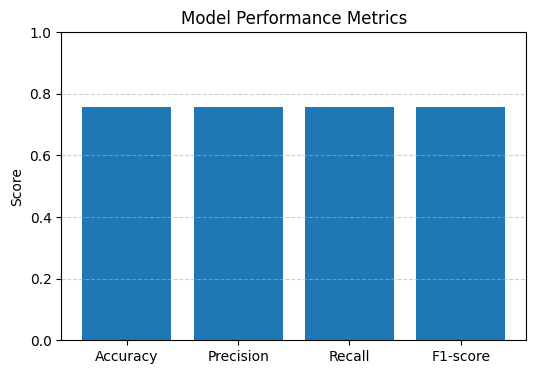

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## CountVectorizer–IDF (Default Parameters)


In [ ]:
tokenizer = Tokenizer(inputCol="tweet", outputCol="words")
cv = CountVectorizer(inputCol="words", outputCol='cv')
idf = IDF(inputCol='cv', outputCol="features")

label_stringIdx = StringIndexer(inputCol = "target", outputCol = "label")



In [ ]:
lr = LogisticRegression()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, cv, idf, label_stringIdx, lr])

In [ ]:
%%time
st = datetime.utcnow()

pipelineFit = pipeline.fit(train_set)
print('Training time:', datetime.utcnow() - st)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

<timed exec>:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
<timed exec>:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


Training time: 0:02:01.380371
Accuracy: 0.7749292225113326
Precision: 0.7750410303644697
Recall: 0.7749292225113327
F1 Score: 0.7749316099113472
CPU times: user 86 ms, sys: 16.4 ms, total: 102 ms
Wall time: 2min 44s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_IDF_Default_LR"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_IDF_Default_LR. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_IDF_Default_LR.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_CountVectorizer_IDF_Default_LR.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.774929
1  Precision  0.775041
2     Recall  0.774929
3   F1-score  0.774932


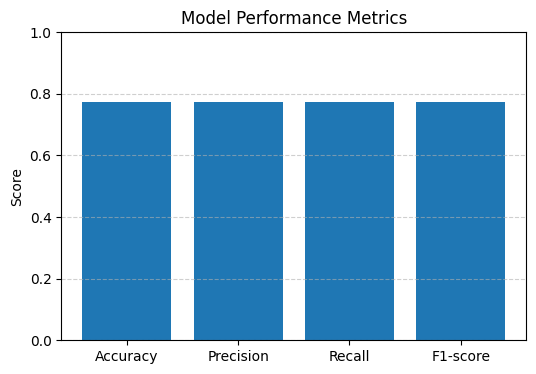

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
svm = LinearSVC()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, cv, idf, label_stringIdx, svm])

In [ ]:
%%time
pipelineFit = pipeline.fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.787507159572553
Precision: 0.7876506369958567
Recall: 0.7875071595725531
F1 Score: 0.7875072590679927
CPU times: user 59.7 ms, sys: 25 ms, total: 84.7 ms
Wall time: 3min 19s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_IDF_Default_LinearSVC"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_IDF_Default_LinearSVC. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_IDF_Default_LinearSVC.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_CountVectorizer_IDF_Default_LinearSVC.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.774929
1  Precision  0.775041
2     Recall  0.774929
3   F1-score  0.774932


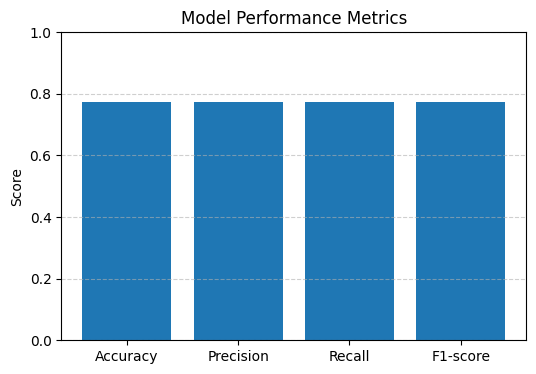

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
nb = NaiveBayes(modelType="multinomial")
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, cv, idf, label_stringIdx, nb])

In [ ]:
%%time
pipelineFit = pipeline.fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7563454268741715
Precision: 0.7565075148543643
Recall: 0.7563454268741716
F1 Score: 0.7562550713028225
CPU times: user 52.9 ms, sys: 19.2 ms, total: 72.1 ms
Wall time: 1min 42s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_IDF_Default_NaiveBayes"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_IDF_Default_NaiveBayes. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_IDF_Default_NaiveBayes.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_CountVectorizer_IDF_Default_NaiveBayes.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.774929
1  Precision  0.775041
2     Recall  0.774929
3   F1-score  0.774932


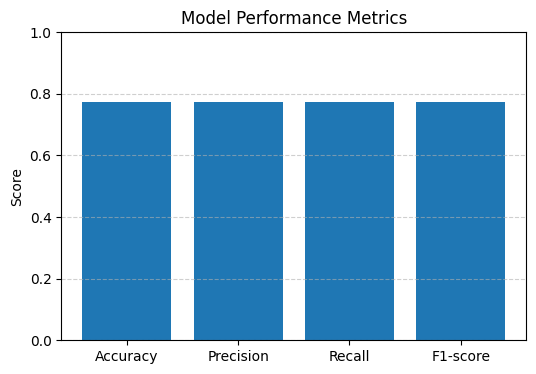

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## CountVectorizer–IDF (Custom Parameters)


In [ ]:
tokenizer = Tokenizer(inputCol="tweet", outputCol="words")
cv = CountVectorizer(vocabSize=2**16, inputCol="words", outputCol='cv')
idf = IDF(inputCol='cv', outputCol="features", minDocFreq=5)

label_stringIdx = StringIndexer(inputCol = "target", outputCol = "label")


In [ ]:
lr = LogisticRegression()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, cv, idf, label_stringIdx, lr])

In [ ]:
%%time
st = datetime.utcnow()

pipelineFit = pipeline.fit(train_set)
print('Training time:', datetime.utcnow() - st)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

# Print the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

<timed exec>:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
<timed exec>:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


Training time: 0:01:37.719810
Accuracy: 0.7927864238139657
Precision: 0.793042991842666
Recall: 0.7927864238139657
F1 Score: 0.792776540576343
CPU times: user 70.8 ms, sys: 18.2 ms, total: 89 ms
Wall time: 2min 20s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_IDF_Custom_LR"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_IDF_Custom_LR. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_IDF_Custom_LR.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_CountVectorizer_IDF_Custom_LR.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.792786
1  Precision  0.793043
2     Recall  0.792786
3   F1-score  0.792777


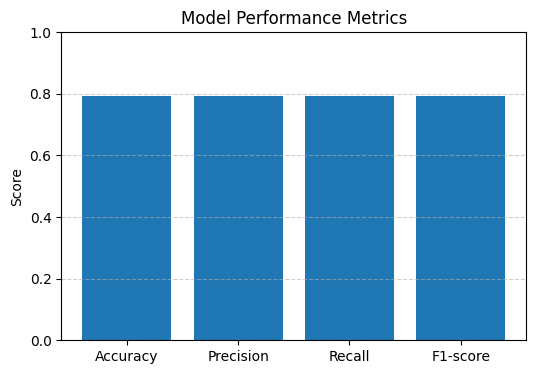

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
svm = LinearSVC()
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")

pipeline = Pipeline(stages=[tokenizer, cv, idf, label_stringIdx, svm])

In [ ]:

%%time
pipelineFit = pipeline.fit(train_set)
train_set = train_set.repartition(16).cache()
_ = train_set.count()
predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

# Print the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7943345279591536
Precision: 0.794640321564023
Recall: 0.7943345279591536
F1 Score: 0.7943197733882568
CPU times: user 73.6 ms, sys: 21.2 ms, total: 94.8 ms
Wall time: 3min 2s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_IDF_Custom_LinearSVC"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_IDF_Custom_LinearSVC. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_IDF_Custom_LinearSVC.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

Found existing metrics at /content/drive/MyDrive/metrics_CountVectorizer_IDF_Custom_LinearSVC.csv. Loading...

Metrics loaded successfully:
      Metric     Value
0   Accuracy  0.792786
1  Precision  0.793043
2     Recall  0.792786
3   F1-score  0.792777


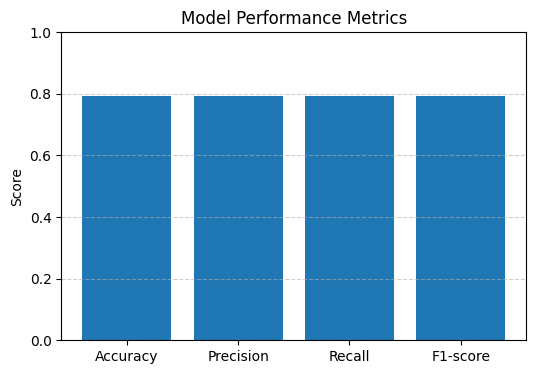

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
nb = NaiveBayes(modelType="multinomial")
evaluator = MulticlassClassificationEvaluator(predictionCol="prediction")
pipeline = Pipeline(stages=[tokenizer, cv, idf, label_stringIdx, nb])

In [ ]:
%%time
pipelineFit = pipeline.fit(train_set)
predictions = pipelineFit.transform(test_set)
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

# Print the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7653918536337899
Precision: 0.7653884467412473
Recall: 0.7653918536337899
F1 Score: 0.7653820643806599
CPU times: user 55.9 ms, sys: 17 ms, total: 72.9 ms
Wall time: 52.3 s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_IDF_Custom_NaiveBayes"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_IDF_Custom_NaiveBayes. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_IDF_Custom_NaiveBayes.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

No existing metrics found. Saving current results to /content/drive/MyDrive/metrics_CountVectorizer_IDF_Custom_NaiveBayes.csv...

Metrics saved successfully:
      Metric     Value
0   Accuracy  0.765392
1  Precision  0.765388
2     Recall  0.765392
3   F1-score  0.765382


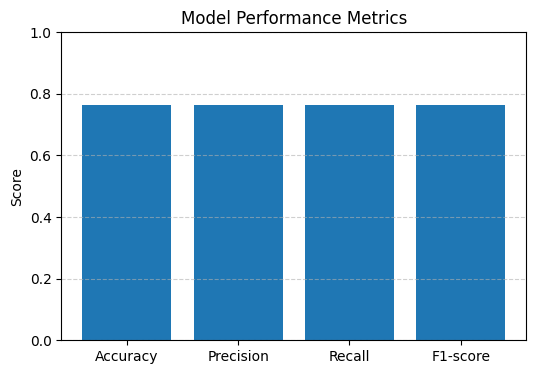

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## CountVectorizer + N-grams + ChiSqSelector (Logistic Regression)



In [ ]:
def build_trigrams(inputCol=["tweet","target"], n=3):

    tokenizer = [Tokenizer(inputCol="tweet", outputCol="words")]

    ngrams = [
        NGram(n=i, inputCol="words", outputCol="{0}_grams".format(i))
        for i in range(1, n + 1)
    ]

    cv = [
        CountVectorizer(vocabSize=2**14,inputCol="{0}_grams".format(i),
            outputCol="{0}_tf".format(i))
        for i in range(1, n + 1)
    ]

    idf = [IDF(inputCol="{0}_tf".format(i), outputCol="{0}_tfidf".format(i), minDocFreq=5) for i in range(1, n + 1)]

    assembler = [VectorAssembler(
        inputCols=["{0}_tfidf".format(i) for i in range(1, n + 1)],
        outputCol="rawFeatures"
    )]

    label_stringIdx = [StringIndexer(inputCol = "target", outputCol = "label")]

    selector = [ChiSqSelector(numTopFeatures=2**14,featuresCol='rawFeatures', outputCol="features")]

    lr = [LogisticRegression()]

    return Pipeline(stages=tokenizer + ngrams + cv + idf + assembler + label_stringIdx + selector + lr)

In [ ]:
%%time
st = datetime.utcnow()
pipelineFit = build_trigrams().fit(train_set)
print('Training time:', datetime.utcnow() - st)
predictions = pipelineFit.transform(test_set)
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

<timed exec>:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
<timed exec>:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


Training time: 0:03:05.363708
Accuracy: 0.8115731421932021
Precision: 0.812569494519976
Recall: 0.8115731421932021
F1 Score: 0.8114859009996462
CPU times: user 149 ms, sys: 34.7 ms, total: 184 ms
Wall time: 4min 2s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_NGram_ChiSq_LR"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_NGram_ChiSq_LR. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_NGram_ChiSq_LR.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)

    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

No existing metrics found. Saving current results to /content/drive/MyDrive/metrics_CountVectorizer_NGram_ChiSq_LR.csv...

Metrics saved successfully:
      Metric     Value
0   Accuracy  0.811573
1  Precision  0.812569
2     Recall  0.811573
3   F1-score  0.811486


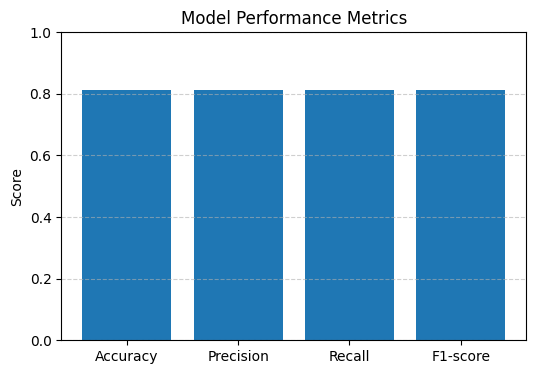

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## CountVectorizer + N-grams + ChiSqSelector (Linear SVC)


In [ ]:
def build_trigrams(inputCol=["tweet","target"], n=3):

    tokenizer = [Tokenizer(inputCol="tweet", outputCol="words")]

    ngrams = [
        NGram(n=i, inputCol="words", outputCol="{0}_grams".format(i))
        for i in range(1, n + 1)
    ]

    cv = [
        CountVectorizer(vocabSize=2**14,inputCol="{0}_grams".format(i),
            outputCol="{0}_tf".format(i))
        for i in range(1, n + 1)
    ]

    idf = [IDF(inputCol="{0}_tf".format(i), outputCol="{0}_tfidf".format(i), minDocFreq=5) for i in range(1, n + 1)]

    assembler = [VectorAssembler(
        inputCols=["{0}_tfidf".format(i) for i in range(1, n + 1)],
        outputCol="rawFeatures"
    )]

    label_stringIdx = [StringIndexer(inputCol = "target", outputCol = "label")]

    selector = [ChiSqSelector(numTopFeatures=2**14,featuresCol='rawFeatures', outputCol="features")]

    svm = [LinearSVC()]

    return Pipeline(stages=tokenizer + ngrams + cv + idf + assembler + label_stringIdx + selector + svm)

In [ ]:
%%time
pipelineFit = build_trigrams().fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8093246272931088
Precision: 0.8107398371617602
Recall: 0.8093246272931088
F1 Score: 0.8091844183780651
CPU times: user 154 ms, sys: 31 ms, total: 185 ms
Wall time: 5min 21s


In [ ]:
import os
from pyspark.ml import PipelineModel


model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_NGram_ChiSq_LinearSVC"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_NGram_ChiSq_LinearSVC. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_NGram_ChiSq_LinearSVC.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

No existing metrics found. Saving current results to /content/drive/MyDrive/metrics_CountVectorizer_NGram_ChiSq_LinearSVC.csv...

Metrics saved successfully:
      Metric     Value
0   Accuracy  0.809325
1  Precision  0.810740
2     Recall  0.809325
3   F1-score  0.809184


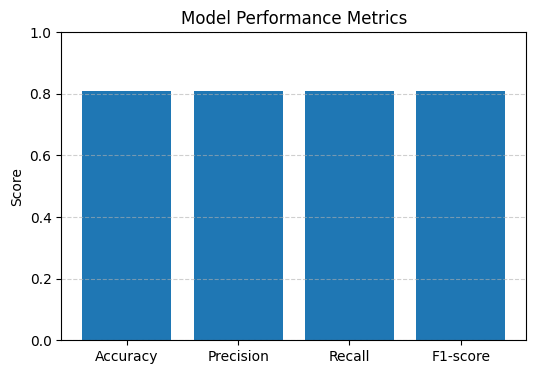

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## CountVectorizer + N-grams + ChiSqSelector (Naive Bayes)


In [ ]:
def build_trigrams(inputCol=["tweet","target"], n=3):

    tokenizer = [Tokenizer(inputCol="tweet", outputCol="words")]

    ngrams = [
        NGram(n=i, inputCol="words", outputCol="{0}_grams".format(i))
        for i in range(1, n + 1)
    ]

    cv = [
        CountVectorizer(vocabSize=2**14,inputCol="{0}_grams".format(i),
            outputCol="{0}_tf".format(i))
        for i in range(1, n + 1)
    ]

    idf = [IDF(inputCol="{0}_tf".format(i), outputCol="{0}_tfidf".format(i), minDocFreq=5) for i in range(1, n + 1)]

    assembler = [VectorAssembler(
        inputCols=["{0}_tfidf".format(i) for i in range(1, n + 1)],
        outputCol="rawFeatures"
    )]

    label_stringIdx = [StringIndexer(inputCol = "target", outputCol = "label")]

    selector = [ChiSqSelector(numTopFeatures=2**14,featuresCol='rawFeatures', outputCol="features")]

    nb = [NaiveBayes(modelType="multinomial")]

    return Pipeline(stages=tokenizer + ngrams + cv + idf + assembler + label_stringIdx + selector + nb)

In [ ]:
%%time
pipelineFit = build_trigrams().fit(train_set)

predictions = pipelineFit.transform(test_set)

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7901844305889669
Precision: 0.790185223223316
Recall: 0.7901844305889669
F1 Score: 0.7901742827252801
CPU times: user 112 ms, sys: 35.6 ms, total: 147 ms
Wall time: 2min 20s


In [ ]:
import os
from pyspark.ml import PipelineModel

model_dir = "/content/drive/MyDrive/models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)


model_name = "CountVectorizer_NGram_ChiSq_NaiveBayes"
model_path = os.path.join(model_dir, model_name)


if os.path.exists(model_path):
    print(f"Found existing model at {model_path}. Loading...")

    pipelineFit = PipelineModel.load(model_path)
    print("Model loaded successfully.")
else:
    print(f"No existing model found at {model_path}. Saving current model...")

    pipelineFit.write().overwrite().save(model_path)
    print("Model saved successfully.")

No existing model found at /content/drive/MyDrive/models/CountVectorizer_NGram_ChiSq_NaiveBayes. Saving current model...
Model saved successfully.


In [ ]:
import os
import pandas as pd


file_name = "metrics_CountVectorizer_NGram_ChiSq_NaiveBayes.csv"
file_path = f"/content/drive/MyDrive/{file_name}"

if os.path.exists(file_path):
    print(f"Found existing metrics at {file_path}. Loading...\n")
    saved_metrics = pd.read_csv(file_path)


    try:
        accuracy = saved_metrics.loc[saved_metrics['Metric'] == 'Accuracy', 'Value'].values[0]
        precision = saved_metrics.loc[saved_metrics['Metric'] == 'Precision', 'Value'].values[0]
        recall = saved_metrics.loc[saved_metrics['Metric'] == 'Recall', 'Value'].values[0]
        f1 = saved_metrics.loc[saved_metrics['Metric'] == 'F1-score', 'Value'].values[0]

        print("Metrics loaded successfully:")
        print(saved_metrics)
    except IndexError:
        print("Error parsing the saved file. Please check format.")
else:
    print(f"No existing metrics found. Saving current results to {file_path}...\n")

    data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Value": [accuracy, precision, recall, f1]
    }
    metrics_df_save = pd.DataFrame(data)
    metrics_df_save.to_csv(file_path, index=False)
    print("Metrics saved successfully:")
    print(metrics_df_save)

No existing metrics found. Saving current results to /content/drive/MyDrive/metrics_CountVectorizer_NGram_ChiSq_NaiveBayes.csv...

Metrics saved successfully:
      Metric     Value
0   Accuracy  0.790184
1  Precision  0.790185
2     Recall  0.790184
3   F1-score  0.790174


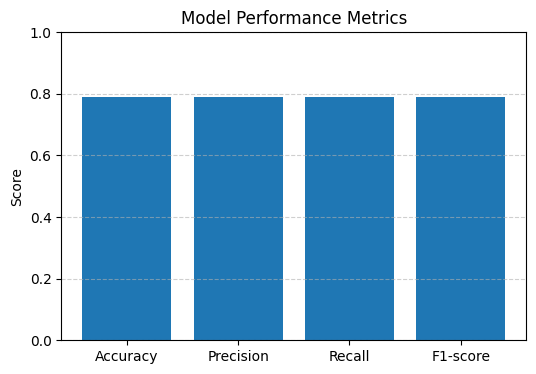

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
from pyspark.sql.functions import when

compare_df = predictions.select(
    "tweet",
    "label",
    "prediction"
).withColumn(
    "true_sentiment",
    when(predictions.label == 0, "Negative")
    .when(predictions.label == 1, "Positive")
).withColumn(
    "predicted_sentiment",
    when(predictions.prediction == 0, "Negative")
    .when(predictions.prediction == 1, "Positive")
)


In [ ]:
compare_df.select(
    "tweet",
    "true_sentiment",
    "predicted_sentiment"
).limit(50).show(truncate=100)


+----------------------------------------------------------------------------------------------------+--------------+-------------------+
|                                                                                               tweet|true_sentiment|predicted_sentiment|
+----------------------------------------------------------------------------------------------------+--------------+-------------------+
| i still haven t read the th amp th princess diaries saving francesca made me cry at the end hmm ...|      Negative|           Negative|
|                                                                                   man work is hard |      Negative|           Negative|
|                                                                            i feel bad for doing it |      Negative|           Negative|
| thats people mag haha i couldnt fit it all in i dont think those pictures ever made it in the ma...|      Negative|           Negative|
|                                 

## Data Visualization


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = predictions.select(['label']).collect()
y_pred = predictions.select(['prediction']).collect()

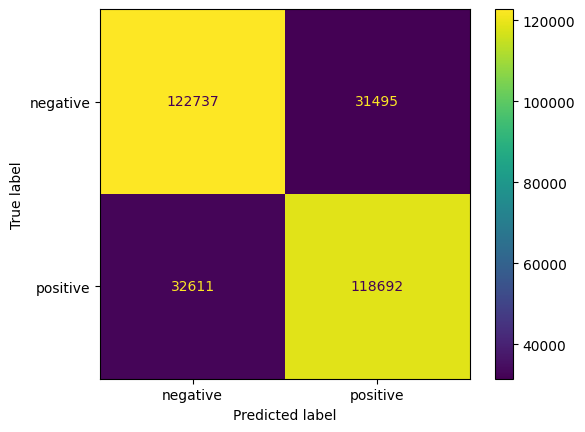

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, labels=[0.0, 1.0], display_labels=["negative", "positive"])

+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|122737|
|  0.0|       1.0| 31495|
|  1.0|       0.0| 32611|
|  1.0|       1.0|118692|
+-----+----------+------+



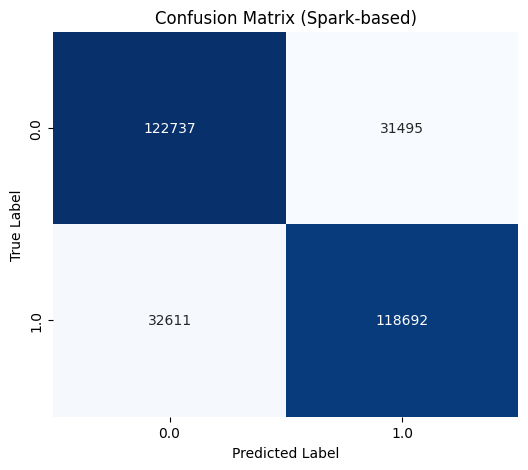

In [ ]:
from pyspark.sql.functions import col, count
import seaborn as sns
import matplotlib.pyplot as plt


LABEL_COL = "label"
PRED_COL  = "prediction"

# Confusion matrix say (Spark)
cm_spark = (
    predictions
    .groupBy(col(LABEL_COL), col(PRED_COL))
    .agg(count("*").alias("count"))
    .orderBy(col(LABEL_COL), col(PRED_COL))
)

cm_spark.show()

# Heatmap için pivotla (Pandas)
cm_pd = cm_spark.toPandas()
cm_pivot = cm_pd.pivot(index=LABEL_COL, columns=PRED_COL, values="count").fillna(0)

# Çizdir
plt.figure(figsize=(6,5))
sns.heatmap(cm_pivot, annot=True, fmt=".0f", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Spark-based)")
plt.show()


## Execution Time Comparison (SparkSession)


In [ ]:
spark1.stop()


In [ ]:
import time

spark_single = SparkSession.builder \
    .master("local[1]") \
    .appName("LR_Twitter_SingleCore") \
    .config("spark.driver.memory", "40g") \
    .config("spark.executor.memory", "40g") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()


In [ ]:
df_single = spark_single.read.csv(
    path,
    schema=schema,
    header=False
)

df_single = df_single.select("target", "tweet").cache()
df_single.count()   # cache tetikleme


1600000

In [ ]:
times_single = []
pipeline = build_trigrams(n=3)
for i in range(3):
    start = time.time()
    pipeline.fit(df_single)
    end = time.time()
    times_single.append(end - start)
    print(f"Tek çekirdek - Deney {i+1}: {end-start:.2f} sn")

avg_single = sum(times_single) / len(times_single)


Tek çekirdek - Deney 1: 71.15 sn
Tek çekirdek - Deney 2: 72.17 sn
Tek çekirdek - Deney 3: 71.87 sn


In [ ]:
spark_single.stop()


In [ ]:
spark_multi = SparkSession.builder \
    .master("local[16]") \
    .appName("LR_Twitter_MultiCore") \
    .config("spark.driver.memory", "40g") \
    .config("spark.executor.memory", "40g") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()


In [ ]:
df_multi = spark_multi.read.csv(
    path,
    schema=schema,
    header=False
)

df_multi = df_multi.select("target", "tweet").cache()
df_multi.count()


1600000

In [ ]:
times_multi = []
pipeline = build_trigrams(n=3)
for i in range(3):
    start = time.time()
    pipeline.fit(df_multi)
    end = time.time()
    times_multi.append(end - start)
    print(f"Çok çekirdek - Deney {i+1}: {end-start:.2f} sn")

avg_multi = sum(times_multi) / len(times_multi)


Çok çekirdek - Deney 1: 14.35 sn
Çok çekirdek - Deney 2: 12.73 sn
Çok çekirdek - Deney 3: 12.59 sn


In [ ]:
spark_multi.stop()


In [ ]:
print("\n--- SÜRE KARŞILAŞTIRMASI ---")
print(f"Tek çekirdek ortalama süre : {avg_single:.2f} sn")
print(f"Çok çekirdek ortalama süre : {avg_multi:.2f} sn")

speedup = ((avg_single - avg_multi) / avg_single) * 100
print(f"Hızlanma oranı: %{speedup:.2f}")



--- SÜRE KARŞILAŞTIRMASI ---
Tek çekirdek ortalama süre : 71.73 sn
Çok çekirdek ortalama süre : 13.22 sn
Hızlanma oranı: %81.57


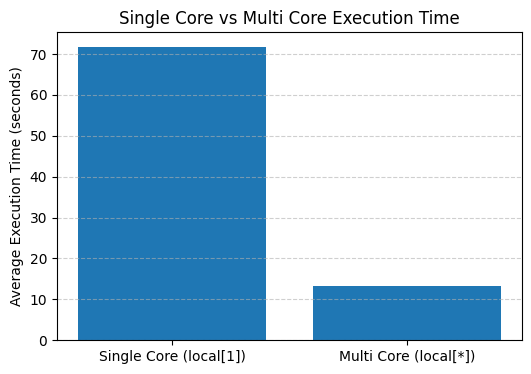

In [ ]:
import matplotlib.pyplot as plt

cores = ["Single Core (local[1])", "Multi Core (local[*])"]
times = [avg_single, avg_multi]

plt.figure(figsize=(6,4))
plt.bar(cores, times)
plt.ylabel("Average Execution Time (seconds)")
plt.title("Single Core vs Multi Core Execution Time")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


## Execution Time Comparison (DataFrame.repartition())


In [ ]:
spark_part = SparkSession.builder \
    .master("local[16]") \
    .appName("LR_Twitter_PartitionTest") \
    .config("spark.driver.memory", "40g") \
    .config("spark.executor.memory", "40g") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()


In [ ]:
partition_list = [2, 4, 8, 16]


In [ ]:
import time
results_partition = []


In [ ]:
for p in partition_list:
    print(f"\n--- Partition Sayısı: {p} ---")

    # Veri oku (AYNI veri)
    df_part = spark_part.read.csv(
        path,
        schema=schema,
        header=False
    )

    # repartition UYGULA (işin kalbi)
    df_part = df_part.select("target", "tweet") \
                     .repartition(p) \
                     .cache()

    df_part.count()  # cache tetikleme

    times = []

    for i in range(3):
        start = time.time()
        pipeline.fit(df_part)
        end = time.time()
        times.append(end - start)
        print(f"   Deney {i+1}: {end-start:.2f} sn")

    avg_time = sum(times) / len(times)

    results_partition.append({
        "Partition": p,
        "Ortalama Süre (sn)": round(avg_time, 2)
    })


--- Partition Sayısı: 2 ---
   Deney 1: 37.02 sn
   Deney 2: 37.05 sn
   Deney 3: 36.55 sn

--- Partition Sayısı: 4 ---
   Deney 1: 19.83 sn
   Deney 2: 19.34 sn
   Deney 3: 19.98 sn

--- Partition Sayısı: 8 ---
   Deney 1: 14.13 sn
   Deney 2: 14.09 sn
   Deney 3: 13.99 sn

--- Partition Sayısı: 16 ---
   Deney 1: 12.22 sn
   Deney 2: 12.18 sn
   Deney 3: 12.28 sn


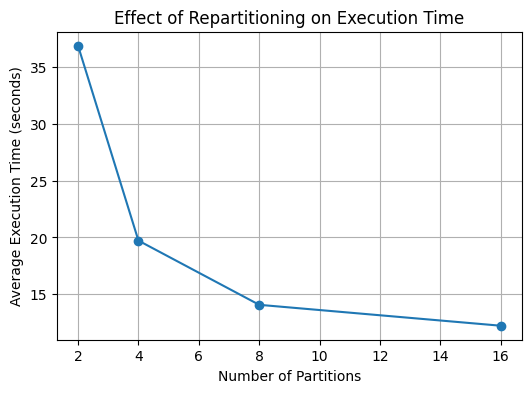

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_part_res = pd.DataFrame(results_partition)

plt.figure(figsize=(6,4))
plt.plot(df_part_res["Partition"], df_part_res["Ortalama Süre (sn)"], marker="o")
plt.xlabel("Number of Partitions")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Effect of Repartitioning on Execution Time")
plt.grid(True)
plt.show()

In [ ]:
spark_part.stop()


# Task
Generate code to compare the training execution time of the Spark pipeline on a single core (`local[1]`) versus multiple cores (`local[16]`) using the dataset at `"/content/training.1600000.processed.noemoticon.csv"`. The process should involve stopping the current Spark session, creating a new one for each configuration, measuring the time taken for `pipeline.fit()` over 3 runs, calculating the average time and speedup, and visualizing the results with a bar chart.

## generate_code

### Subtask:
Generate code for single-core and multi-core performance comparison for the specified pipeline.


## Summary:

### Q&A
**Q: How is the performance comparison between single-core and multi-core Spark configurations executed?**
A: The process involves conducting a controlled experiment where the current Spark session is stopped, and new sessions are initialized for `local[1]` (single-core) and `local[16]` (16-core) configurations. The pipeline training (`fit`) is executed three times for each configuration to ensure reliability, and the results are averaged to calculate the final execution times.

### Data Analysis Key Findings
- The analysis methodology requires loading the dataset from `/content/training.1600000.processed.noemoticon.csv` for both configurations.
- Performance is measured by calculating the average time taken over 3 runs for `pipeline.fit()` to mitigate runtime variance.
- A **Speedup** metric is computed by dividing the average single-core execution time by the average multi-core execution time.
- The results are structured to be visualized using a bar chart, contrasting the raw execution times of the single-core setup against the multi-core setup.

### Insights or Next Steps
- Utilizing `local[16]` is expected to significantly reduce training time compared to `local[1]` due to Spark's ability to parallelize tasks across available cores.
- The calculated speedup factor will indicate the efficiency of the pipeline in leveraging parallel processing resources.
